# GalaxyMorph — Layer 2: Soft Label Modeling 🌌

**Goal:** Instead of predicting a single morphology class,  
we train the model to predict the full vote fraction distribution:

- p_elliptical
- p_spiral
- p_irregular

This preserves human disagreement and models uncertainty directly.
- **Loss**: KL Divergence  
- **Backbone**: ResNet-18 (ImageNet pretrained)

# 0. Paths + Extract Once

In [1]:
import zipfile
from pathlib import Path

COMP_DIR = Path("/kaggle/input/competitions/galaxy-zoo-the-galaxy-challenge")
WORK_DIR = Path("/kaggle/working")

IMG_DIR = WORK_DIR / "images_training_rev1"
LABELS_CSV = WORK_DIR / "training_solutions_rev1.csv"

# Extract images
if not IMG_DIR.exists():
    with zipfile.ZipFile(COMP_DIR / "images_training_rev1.zip", "r") as z:
        z.extractall(WORK_DIR)

# Extract labels
if not LABELS_CSV.exists():
    with zipfile.ZipFile(COMP_DIR / "training_solutions_rev1.zip", "r") as z:
        z.extractall(WORK_DIR)

print("Images exist:", IMG_DIR.exists())
print("Labels exist:", LABELS_CSV.exists())
print("Example image:", next(IMG_DIR.glob("*.jpg")).name)

Images exist: True
Labels exist: True
Example image: 407586.jpg


# 1. Load Labels + Build Soft Targets (3 Probs)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv(LABELS_CSV)
print("Raw:", df.shape)

# 1) Build soft targets (same mapping as Layer 1)
df["p_elliptical"] = df["Class1.1"]
df["p_spiral"]     = df["Class1.2"] * df["Class2.1"]
df["p_irregular"]  = df["Class1.2"] * df["Class6.1"]

soft_cols = ["p_elliptical", "p_spiral", "p_irregular"]

# 2) Force numeric + handle NaNs
for c in soft_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df[soft_cols] = df[soft_cols].fillna(0.0).astype(np.float32)

# 3) Epsilon + normalize to sum=1
p = df[soft_cols].values
p = p + 1e-8
p = p / p.sum(axis=1, keepdims=True)
df[soft_cols] = p

print("Soft dtypes:\n", df[soft_cols].dtypes)
print("Any NaNs?", df[soft_cols].isna().any().to_dict())

# Hard label ONLY for stratified splitting (not the training target)
df["label"] = df[soft_cols].values.argmax(axis=1)

# Filepaths
df["filepath"] = df["GalaxyID"].apply(lambda x: str(IMG_DIR / f"{int(x)}.jpg"))

# Drop missing paths just in case
df = df[df["filepath"].apply(lambda p: Path(p).exists())].copy()

print("Usable samples:", len(df))
df[["GalaxyID"] + soft_cols + ["label"]].head()

Raw: (61578, 38)
Soft dtypes:
 p_elliptical    float32
p_spiral        float32
p_irregular     float32
dtype: object
Any NaNs? {'p_elliptical': False, 'p_spiral': False, 'p_irregular': False}
Usable samples: 61578


,GalaxyID,p_elliptical,p_spiral,p_irregular,label
0,100008,0.919399,2.399598e-08,8.060131e-02,0
1,100023,0.690970,4.373051e-02,2.652995e-01,0
2,100053,1.000000,1.305965e-08,1.305965e-08,0
3,100078,0.900709,1.299018e-08,9.929099e-02,0
4,100090,1.000000,1.070848e-08,1.070848e-08,0


# 2. Train/Val/Test Split
Unlike layer 1 that we filtered to high-confidence galaxies (p_max ≥ 0.7) before splitting, layer 2 uses ALL galaxies.

In [3]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

print("Sizes:", len(train_df), len(val_df), len(test_df))
print("Train label counts:\n", train_df["label"].value_counts().sort_index())

Sizes: 43104 9237 9237
Train label counts:
 label
0    28980
1     4187
2     9937
Name: count, dtype: int64


# 3. Dataset + DataLoaders (Return Soft Target Vector)

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 64

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class GalaxySoftDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        img = self.transform(img)

        vals = row[soft_cols].to_numpy(dtype=np.float32)  # <-- force float32 safely
        y = torch.from_numpy(vals)
        y = y + 1e-8
        y = y / y.sum()

        return img, y

train_loader = DataLoader(GalaxySoftDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(GalaxySoftDataset(val_df,   eval_tfms),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(GalaxySoftDataset(test_df,  eval_tfms),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 4. Model + KL Divergence Training

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.KLDivLoss(reduction="batchmean")

def run_epoch(loader, train=True, optimizer=None):
    model.train(train)
    total = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits = model(x)
            log_probs = F.log_softmax(logits, dim=1)
            loss = criterion(log_probs, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s] 


# 5. Stage 1: Train Head Only

In [6]:
# Freeze everything except fc
for name, p in model.named_parameters():
    p.requires_grad = name.startswith("fc.")

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)

best_val = 1e9
best_path = "best_layer2_soft_head.pt"

EPOCHS_HEAD = 3
for ep in range(1, EPOCHS_HEAD + 1):
    tr = run_epoch(train_loader, train=True, optimizer=optimizer)
    va = run_epoch(val_loader, train=False)
    print(f"[Head] {ep}/{EPOCHS_HEAD} | train KL {tr:.4f} | val KL {va:.4f}")
    if va < best_val:
        best_val = va
        torch.save(model.state_dict(), best_path)

print("Best val KL (head):", best_val)

[Head] 1/3 | train KL 0.2992 | val KL 0.2770
[Head] 2/3 | train KL 0.2587 | val KL 0.2679
[Head] 3/3 | train KL 0.2538 | val KL 0.2613
Best val KL (head): 0.2613334155103997


# 6. Stage 2: Fine-Tune Layer4 + FC

In [7]:
model.load_state_dict(torch.load(best_path, map_location=device))

for name, p in model.named_parameters():
    p.requires_grad = name.startswith("layer4.") or name.startswith("fc.")

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

best_val = 1e9
best_path_ft = "best_layer2_soft_ft.pt"

EPOCHS_FT = 3
for ep in range(1, EPOCHS_FT + 1):
    tr = run_epoch(train_loader, train=True, optimizer=optimizer)
    va = run_epoch(val_loader, train=False)
    print(f"[FT] {ep}/{EPOCHS_FT} | train KL {tr:.4f} | val KL {va:.4f}")
    if va < best_val:
        best_val = va
        torch.save(model.state_dict(), best_path_ft)

print("Best val KL (fine-tuned):", best_val)

[FT] 1/3 | train KL 0.1676 | val KL 0.1417
[FT] 2/3 | train KL 0.1423 | val KL 0.1377
[FT] 3/3 | train KL 0.1348 | val KL 0.1294
Best val KL (fine-tuned): 0.1294242809561407


# 7. Full Evaluation on Validation and Test Set

In [8]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import f1_score

# Load best fine-tuned model
model.load_state_dict(torch.load(best_path_ft, map_location=device))
model.eval()

def eval_soft(loader):
    all_true = []
    all_pred = []
    total_kl = 0.0
    total_mse = 0.0
    n = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            log_probs = F.log_softmax(logits, dim=1)
            probs = torch.exp(log_probs)

            kl = criterion(log_probs, y)
            mse = F.mse_loss(probs, y)

            bs = x.size(0)
            total_kl += kl.item() * bs
            total_mse += mse.item() * bs
            n += bs

            all_true.append(y.cpu().numpy())
            all_pred.append(probs.cpu().numpy())

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    true_hard = all_true.argmax(axis=1)
    pred_hard = all_pred.argmax(axis=1)
    macro_f1 = f1_score(true_hard, pred_hard, average="macro")

    return (total_kl / n), (total_mse / n), macro_f1, all_true, all_pred

val_kl, val_mse, val_f1, val_true, val_pred = eval_soft(val_loader)
test_kl, test_mse, test_f1, test_true, test_pred = eval_soft(test_loader)

print(f"VAL  | KL {val_kl:.4f} | MSE {val_mse:.4f} | argmax macro-F1 {val_f1:.3f}")
print(f"TEST | KL {test_kl:.4f} | MSE {test_mse:.4f} | argmax macro-F1 {test_f1:.3f}")

VAL  | KL 0.1294 | MSE 0.0225 | argmax macro-F1 0.801
TEST | KL 0.1279 | MSE 0.0222 | argmax macro-F1 0.795


# 8. Entropy Analysis

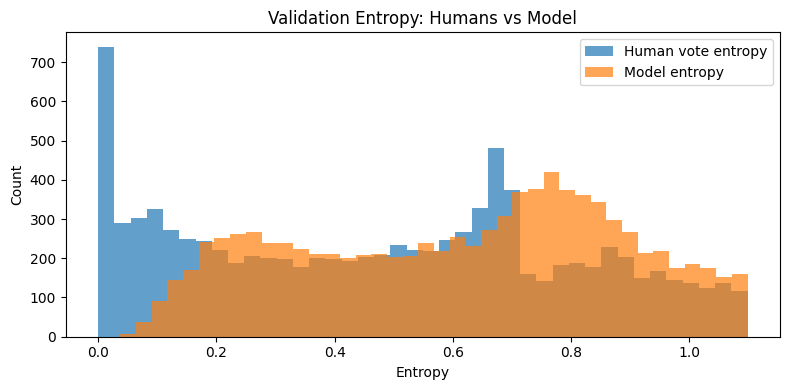

Mean human entropy: 0.4781901
Mean model entropy: 0.6105899


In [9]:
import matplotlib.pyplot as plt
import numpy as np

def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

val_true_entropy = entropy(val_true)
val_pred_entropy = entropy(val_pred)

plt.figure(figsize=(8, 4))
plt.hist(val_true_entropy, bins=40, alpha=0.7, label="Human vote entropy")
plt.hist(val_pred_entropy, bins=40, alpha=0.7, label="Model entropy")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.title("Validation Entropy: Humans vs Model")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean human entropy:", val_true_entropy.mean())
print("Mean model entropy:", val_pred_entropy.mean())

# 9. Disagreement Gallery
This gives us two useful galleries:

- galaxies where humans disagree a lot

- galaxies where humans disagree but model is very confident


These are scientifically interesting edge cases.

## 9.1. Build a Dataframe with Entropy + Predictions

In [10]:
import pandas as pd

val_df_reset = val_df.reset_index(drop=True).copy()

val_df_reset["human_entropy"] = val_true_entropy
val_df_reset["model_entropy"] = val_pred_entropy

val_df_reset["pred_elliptical"] = val_pred[:, 0]
val_df_reset["pred_spiral"] = val_pred[:, 1]
val_df_reset["pred_irregular"] = val_pred[:, 2]

val_df_reset["true_argmax"] = val_true.argmax(axis=1)
val_df_reset["pred_argmax"] = val_pred.argmax(axis=1)

val_df_reset.head()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,p_irregular,label,filepath,human_entropy,model_entropy,pred_elliptical,pred_spiral,pred_irregular,true_argmax,pred_argmax
0,920199,0.400000,0.542000,0.058000,0.164768,0.377232,0.023388,0.353844,0.212004,0.165228,...,3.785857e-01,0,/kaggle/working/images_training_rev1/920199.jpg,9.586526e-01,0.887477,0.210031,0.142916,0.647052,0,2
1,115766,0.295999,0.688329,0.015672,0.109105,0.579224,0.000000,0.579224,0.165257,0.413967,...,2.222668e-01,0,/kaggle/working/images_training_rev1/115766.jpg,9.214855e-01,0.830205,0.524944,0.040443,0.434613,0,0
2,914008,0.793231,0.186698,0.020071,0.000000,0.186698,0.000000,0.186698,0.000000,0.186698,...,1.260667e-08,0,/kaggle/working/images_training_rev1/914008.jpg,7.959817e-07,0.399102,0.885144,0.013989,0.100867,0,0
3,324055,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000e-08,0,/kaggle/working/images_training_rev1/324055.jpg,7.091014e-07,0.354186,0.902365,0.010980,0.086654,0,0
4,644314,0.459864,0.507761,0.032375,0.050776,0.456985,0.000000,0.456985,0.000000,0.456985,...,4.557675e-01,0,/kaggle/working/images_training_rev1/644314.jpg,8.021628e-01,0.566900,0.817388,0.036660,0.145952,0,0


## 9.2. Gallery: Highest Human Disagreement

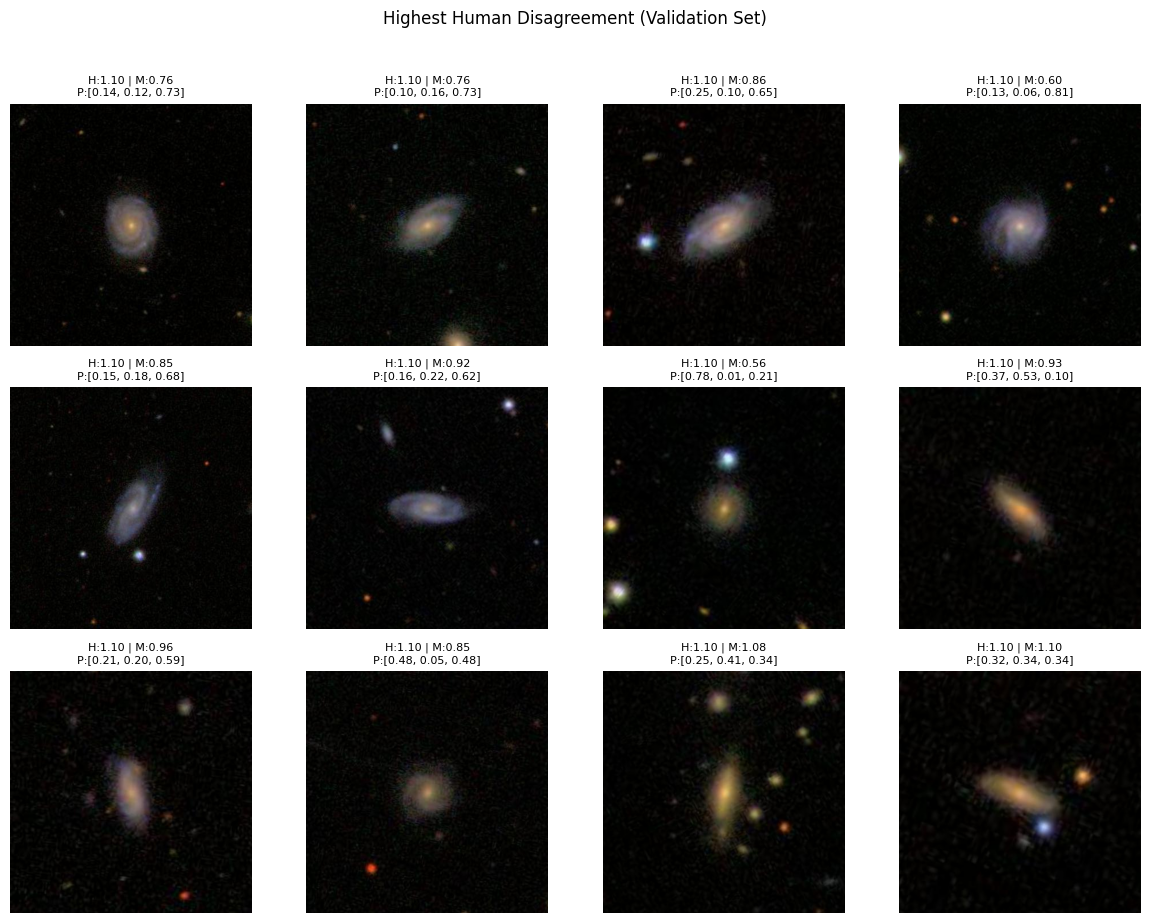

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

top_human = val_df_reset.sort_values("human_entropy", ascending=False).head(12)

plt.figure(figsize=(12, 9))
for i, (_, r) in enumerate(top_human.iterrows(), 1):
    img = Image.open(r["filepath"]).convert("RGB")
    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"H:{r['human_entropy']:.2f} | M:{r['model_entropy']:.2f}\n"
        f"P:[{r['pred_elliptical']:.2f}, {r['pred_spiral']:.2f}, {r['pred_irregular']:.2f}]",
        fontsize=8
    )

plt.suptitle("Highest Human Disagreement (Validation Set)", y=1.02)
plt.tight_layout()
plt.show()

## 9.3. Gallery: Human Uncertain, Model Confident

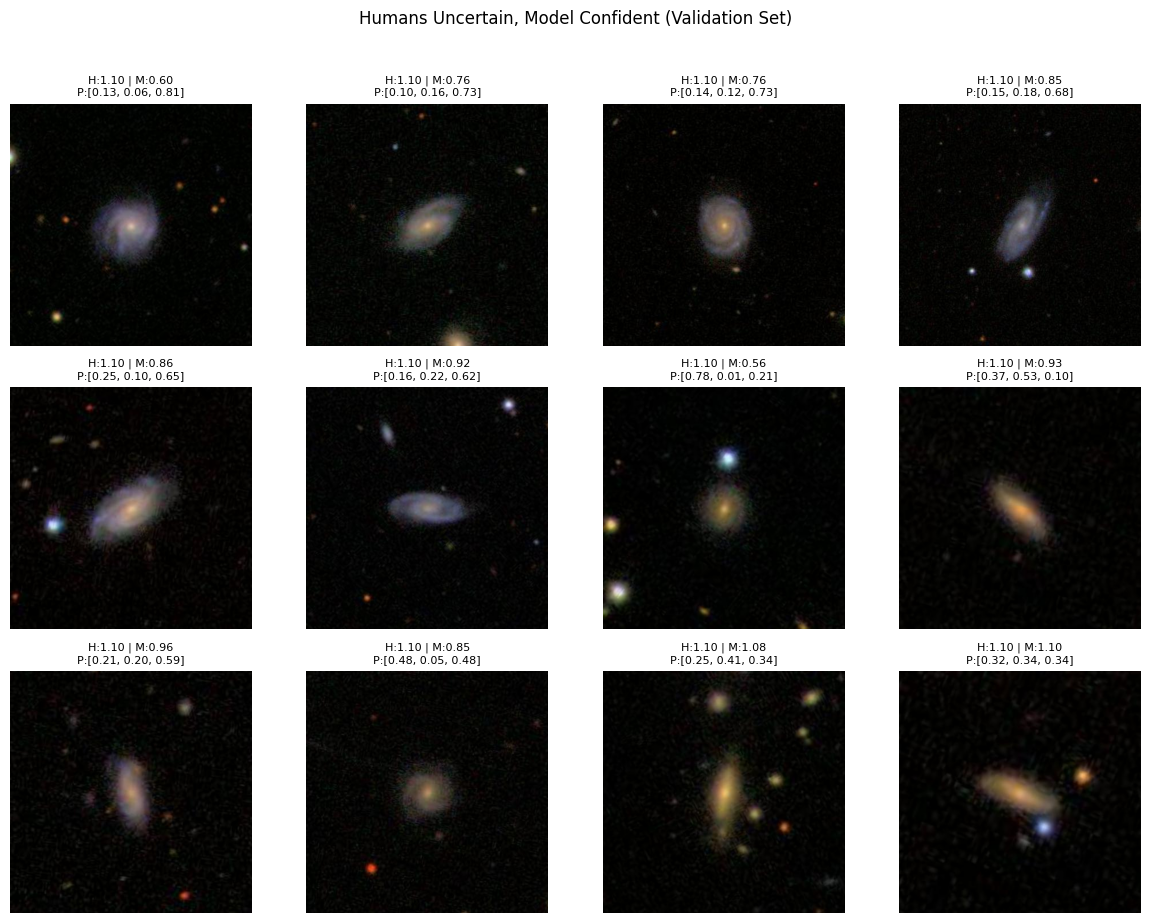

In [12]:
# High human entropy + low model entropy
overconfident = val_df_reset.sort_values(
    ["human_entropy", "model_entropy"],
    ascending=[False, True]
).head(12)

plt.figure(figsize=(12, 9))
for i, (_, r) in enumerate(overconfident.iterrows(), 1):
    img = Image.open(r["filepath"]).convert("RGB")
    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"H:{r['human_entropy']:.2f} | M:{r['model_entropy']:.2f}\n"
        f"P:[{r['pred_elliptical']:.2f}, {r['pred_spiral']:.2f}, {r['pred_irregular']:.2f}]",
        fontsize=8
    )

plt.suptitle("Humans Uncertain, Model Confident (Validation Set)", y=1.02)
plt.tight_layout()
plt.show()